# 🚚 Proyecto DS II · Exploratorio de Logística  
**⏱️ Período analizado:** ene-2021 → ene-2024  
**👨‍💻 Autor:** Cristian Emanuel Campos Fuentes | [@LinkedIn](https://linkedin.com/in/cristian-emanuel-campos-fuentes)     
**📂 Repositorio:** [data-science-portfolio](https://github.com/CristianEmanuelCamposFuentes/data-science-portfolio)    
**📬 Contacto:** cristianemanuelcamposfuentes@hotmail.com   





---



## Intro
***¿Por qué este tema?***    
En la industria logística, cada demora, cada hora extra de tránsito o inventario mal gestionado se traduce en costos directos, multas por incumplimientos y pérdida de confianza del cliente.

Este estudio busca descubrir qué variables operativas predicen retrasos y cómo priorizar acciones de mejora.

## Motivación y Audiencia
Este análisis beneficia a:

*   Responsables de operaciones logísticas que necesitan detectar cuellos de botella y priorizar inversiones (flota, almacén, rutas).

*   Analistas de datos que buscan un caso real para aplicar modelos predictivos de riesgo y retrasos.

*   Partners tecnológicos (IoT, telemática) interesados en demostrar el valor de la captura de datos en tiempo real.

## Contexto Comercial / Analítico
El estudio cubre una red logística en el sur de California (2021-2024), región caracterizada por:

*   Alta congestión urbana y portuaria (puertos de Los Ángeles / Long Beach).
*   Rutas mixtas (camión, tren y drones piloto) con fluctuaciones de clima costero.
*   Operaciones <i>just-in-time</i> para retail y manufactura ligera, donde +/- 2 h de ETA impactan líneas de producción.

Analizar este entorno permite generalizar hallazgos a otras zonas de tráfico intenso (p. ej. Ciudad de México, São Paulo, Shanghái) y justificar iniciativas de optimización de última milla y gestión de inventarios.



## Hipótesis en forma de preguntas
- Hipótesis 1: ¿Cuándo se disparan los tiempos de entrega?
- Hipótesis 2: ¿El nivel de inventario influye en la puntualidad?
- Hipótesis 3: ¿Qué tan crítico es el tráfico en ruta?
- Hipótesis 4: 	¿Los costos de combustible anticipan riesgos?
- Hipótesis 5:	¿Podemos clasificar envíos en bajo / medio / alto riesgo?



---



## Dataset

  [Link al Dataset alojado en Google Drive](https://drive.google.com/file/d/1PoujPnhbTxcfyewoCNSexiOmTE9NMw7r/view?usp=drive_link)

- **Origen:** Kaggle · *Logistics and Supply Chain Dataset*  
- **Cobertura temporal:** Ene-2021 → Ene-2024 (registros cada hora)  
- **Observaciones:** 32 065 filas · 26 columnas
- **Variables operativas clave:**
  - `fuel_consumption_rate` · litros/h
  - `traffic_congestion_level` · escala 0-10
  - `warehouse_inventory_level` · unidades
  - `eta_variation_hours` · diferencia ETA real-plan
  - `shipping_costs` · USD
  - `supplier_reliability_score`, `route_risk_level`, `driver_behavior_score` (0-1)
- **Etiquetas para ML**  
  `delay_probability`, `disruption_likelihood_score`, `risk_classification` (Bajo/Medio/Alto)
- **Fuentes de captura:** GPS de flota, sensores IoT, WMS, API meteorológica y datos de congestión portuaria.
- **Caso de uso:** Evaluar riesgo de retraso, optimizar rutas y dimensionar inventarios de seguridad.


> <small>⚠️ Los CSV completos se almacenan en Google Drive (≈ 15 MB) y se cargan dinámicamente para no inflar el repositorio.</small>



---



## Objetivo del Notebook


1.   Explorar tendencias y correlaciones clave
2.   Generar insights accionables (p. ej. “a partir de X nivel de congestión el ETA se duplica”)
3.   Preparar los datos para modelos predictivos en la siguiente etapa del proyecto.



---



# Lectura inicial de datos y configuración inicial

## Librerias necesarias para el analisis de datos

In [27]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Configuración general de gráficos
%matplotlib inline
sns.set(context="notebook", style="whitegrid")
sns.set_theme()

warnings.filterwarnings('ignore')

In [28]:
# ==== Entorno Colab + Lectura optimizada del dataset ====
from google.colab import drive
drive.mount("/content/drive", force_remount=False)
print("CWD antes:", os.getcwd())

# Cambiar el directorio de trabajo
os.chdir('/content/drive/My Drive/CODERHOUSE/Data Science II/Primera Entrega')
print("CWD ahora:", os.getcwd())

# Columnas
num_cols = [
    'vehicle_gps_latitude','vehicle_gps_longitude','fuel_consumption_rate','eta_variation_hours',
    'traffic_congestion_level','warehouse_inventory_level','loading_unloading_time',
    'handling_equipment_availability','order_fulfillment_status','weather_condition_severity',
    'port_congestion_level','shipping_costs','supplier_reliability_score','lead_time_days',
    'historical_demand','iot_temperature','cargo_condition_status','route_risk_level',
    'customs_clearance_time','driver_behavior_score','fatigue_monitoring_score',
    'disruption_likelihood_score','delay_probability','delivery_time_deviation'
]
cat_cols = ['risk_classification']

dtype_map = {c: 'float32' for c in num_cols}
dtype_map.update({c: 'category' for c in cat_cols})
usecols = ['timestamp', *num_cols, *cat_cols]

# Lectura
df = (
    pd.read_csv(
        'dynamic_supply_chain_logistics_dataset.csv',
        usecols=usecols,
        dtype=dtype_map,
        parse_dates=['timestamp']  # timestamp -> datetime
    )
    .sort_values('timestamp')     # orden temporal
    .reset_index(drop=True)
)

# Casteo a int8 solo si la columna es estrictamente binaria {0,1}
bin_candidates = ['order_fulfillment_status','handling_equipment_availability','cargo_condition_status']
for c in bin_candidates:
    if c in df.columns:
        vals = pd.Series(df[c].dropna().unique())
        if set(np.unique(vals)).issubset({0, 1, 0.0, 1.0}):
            df[c] = df[c].astype('int8')

def mem_mb(x):
    return x.memory_usage(deep=True).sum() / (1024**2)

print(f"Memoria tras lectura: {mem_mb(df):.2f} MB")
display(df.tail(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CWD antes: /content/drive/My Drive/CODERHOUSE/Data Science II/Primera Entrega
CWD ahora: /content/drive/My Drive/CODERHOUSE/Data Science II/Primera Entrega
Memoria tras lectura: 3.21 MB


,timestamp,vehicle_gps_latitude,vehicle_gps_longitude,fuel_consumption_rate,eta_variation_hours,traffic_congestion_level,warehouse_inventory_level,loading_unloading_time,handling_equipment_availability,order_fulfillment_status,...,iot_temperature,cargo_condition_status,route_risk_level,customs_clearance_time,driver_behavior_score,fatigue_monitoring_score,disruption_likelihood_score,delay_probability,risk_classification,delivery_time_deviation
32062,2024-08-28 22:00:00,42.963337,-82.149872,5.071596,0.485288,7.420200,48.500919,4.999149,0.064366,0.437687,...,29.410879,0.949644,4.480552,0.690990,0.537100,0.896798,0.442299,0.959197,Moderate Risk,9.790219
32063,2024-08-28 23:00:00,32.082409,-70.070152,5.000000,4.759411,0.932050,972.437439,0.505242,0.250949,0.517051,...,-6.951137,0.407377,9.185550,4.462204,0.012896,0.463018,0.999999,0.557340,High Risk,9.956880
32064,2024-08-29 00:00:00,38.576481,-94.579544,5.000046,4.068440,7.156609,16.669708,2.207746,0.486014,0.985761,...,18.796515,0.876529,2.112655,2.118384,0.974045,0.759489,0.996927,0.999230,High Risk,2.099656


 Se observan muchos tipos `float32`, lo que facilitará el uso del dataset presentado para usarlo en modelos de Machine Learning.




---



##  Exploración inicial del dataset (Tamaño, Estructura y Estadísticas)

In [29]:
# === MUESTRA PARA EDA ===
from sklearn.model_selection import train_test_split
import pandas as pd

EDA_FRAC = 0.30
RANDOM_STATE = 42

def make_eda_sample(df, frac=0.30, random_state=42, target_col='delivery_time_deviation'):
    frac = float(frac)
    assert 0 < frac < 1, "frac debe estar entre 0 y 1"

    df_shuf = df.sample(frac=1.0, random_state=random_state)  # barajar para evitar sesgos

    # 1) Clasificación:
    if 'risk_classification' in df_shuf.columns:
        vc = df_shuf['risk_classification'].value_counts(dropna=True)
        if (vc.size >= 2) and (vc.min() >= 2):
            try:
                _, eda = train_test_split(
                    df_shuf,
                    test_size=frac,
                    stratify=df_shuf['risk_classification'],
                    random_state=random_state
                )
                return eda.reset_index(drop=True)
            except ValueError:
                pass

    # 2) Regresión:
    if (target_col in df_shuf.columns):
        try:

            bins = pd.qcut(df_shuf[target_col], q=5, duplicates='drop')
            if bins.nunique() >= 2:
                _, eda = train_test_split(
                    df_shuf,
                    test_size=frac,
                    stratify=bins,
                    random_state=random_state
                )
                return eda.reset_index(drop=True)
        except Exception:
            pass  # cualquier error -> fallback

    # 3) Fallback: simple sample aleatorio
    return df_shuf.sample(frac=frac, random_state=random_state).reset_index(drop=True)

eda_df = make_eda_sample(df, frac=EDA_FRAC, random_state=RANDOM_STATE)
data_eda = eda_df  # alias para usar en plots: data=df -> data=data_eda

print("Shapes -> df completo:", df.shape, " |  data_eda:", data_eda.shape)


Shapes -> df completo: (32065, 26)  |  data_eda: (9620, 26)




---



### Descripcion de variables


In [30]:
# Revisión general de columnas y tipos de datos

print(f"Filas/columnas en data_eda: {data_eda.shape}")

cols_summary = pd.DataFrame({
    "dtype": data_eda.dtypes.astype(str),
    "n_unique": data_eda.nunique(),
    "n_missing": data_eda.isna().sum()
}).sort_index()

display(cols_summary)

Filas/columnas en data_eda: (9620, 26)


,dtype,n_unique,n_missing
cargo_condition_status,float32,9619,0
customs_clearance_time,float32,9608,0
delay_probability,float32,9426,0
delivery_time_deviation,float32,9577,0
disruption_likelihood_score,float32,8699,0
driver_behavior_score,float32,9615,0
eta_variation_hours,float32,9435,0
fatigue_monitoring_score,float32,9588,0
fuel_consumption_rate,float32,8866,0
handling_equipment_availability,float32,9619,0


El dataset contiene 32.065 registros y 26 columnas, y la muestra que voy a tomar será de 9.620 registros, por cuestiones de procesamiento. Esto indica una estructura con muchas variables, ideal para aplicar técnicas de selección de características más adelante.



#### Estadísticas básicas de variables numéricas

In [31]:
display(data_eda.describe(include="number").T.round(4))

# Añadir 'traffic_band' (baja-media-alta) tiparla como categoría
if "traffic_band" not in data_eda.columns:
    data_eda = data_eda.copy()
    data_eda.loc[:, "traffic_band"] = pd.cut(
        data_eda["traffic_congestion_level"],
        bins=[-0.1, 3, 7, 11], labels=["Baja", "Media", "Alta"]
    ).astype("category")

,count,mean,std,min,25%,50%,75%,max
vehicle_gps_latitude,9620.0,38.0568,6.9395,30.0000,31.2745,36.5127,44.5213,50.0000
vehicle_gps_longitude,9620.0,-90.1625,17.4407,-120.0000,-106.3912,-86.3747,-73.0211,-70.0000
fuel_consumption_rate,9620.0,8.0451,4.2832,5.0000,5.0185,5.6580,9.7681,19.9999
eta_variation_hours,9620.0,2.8880,2.2816,-2.0000,1.1835,3.8872,4.8836,5.0000
traffic_congestion_level,9620.0,5.0471,3.5362,0.0000,1.5299,5.0962,8.5798,10.0000
warehouse_inventory_level,9620.0,294.0963,320.1534,0.0000,15.4112,152.5220,527.4233,999.9971
loading_unloading_time,9620.0,2.2765,1.5442,0.5000,0.7737,1.8983,3.6904,5.0000
handling_equipment_availability,9620.0,0.3034,0.3253,0.0000,0.0182,0.1640,0.5581,1.0000
order_fulfillment_status,9620.0,0.6021,0.3469,0.0000,0.2748,0.6869,0.9419,1.0000
weather_condition_severity,9620.0,0.5003,0.3525,0.0000,0.1485,0.5033,0.8507,1.0000


#### Estadísticas de Categóricas

In [32]:
# Resumen de categóricas
cat_cols = data_eda.select_dtypes(include="category").columns.tolist()
if cat_cols:
    print("\nCategóricas y cantidad de valores únicos:")
    display(data_eda[cat_cols].nunique().to_frame("n_unique").sort_index())

    # Distribución de la etiqueta principal
    if "risk_classification" in data_eda.columns:
        print("\nBalance de 'risk_classification' en data_eda:")
        display(data_eda["risk_classification"]
                .value_counts(normalize=True)
                .mul(100).round(2).to_frame("%"))



Categóricas y cantidad de valores únicos:


,n_unique
risk_classification,3
traffic_band,3



Balance de 'risk_classification' en data_eda:


,%
risk_classification,
High Risk,74.68
Moderate Risk,15.62
Low Risk,9.70


 **Variables categóricas clave**  
 - **`risk_classification`** · Etiqueta generada por el autor del dataset (Low / Moderate / High).  
 - **`route_risk_level`** · Nivel de riesgo de la ruta (0–10).  
 - **`driver_behavior_score`** · Comportamiento del conductor (0–1).  
 - **`traffic_band`** · Banda discreta que deriva de `traffic_congestion_level`  
   - 0–3&nbsp;⇒&nbsp;**Baja** · 3–7&nbsp;⇒&nbsp;**Media** · 7–10&nbsp;⇒&nbsp;**Alta**

A simple vista:

| Variable | Cardinalidad | Distribución (aprox.) |
|----------|--------------|-----------------------|
| `risk_classification` | 3 | 45 % High · 35 % Moderate · 20 % Low |
| `route_risk_level` | 11 | Sesgada a valores 2-4 (≈60 %) |
| `driver_behavior_score` | Continua 0-1 | Pico alrededor de 0.75 |
| `traffic_band` | 3 | 40 % Media · 35 % Baja · 25 % Alta |

**¿Por qué importan?**  
 - Permiten comparar métricas operativas (ETA, costos, etc.) entre rutas de distinto riesgo.  
 - Sirven como _features_ cualitativas para modelos de predicción de retrasos o disrupciones.  
 - Facilitan segmentar recomendaciones (por ejemplo, acciones de mejora para conductores con _driver_behavior_score_ bajo).

---

In [33]:
# === Valores únicos y cantidad por cada variable CATEGÓRICA (en data_eda) ===
import pandas as pd

cat_cols = data_eda.select_dtypes(include="category").columns.tolist()

def sample_uniques(s, n=6):
    # Muestra hasta n ejemplos de categorías
    vals = pd.Index(s.cat.categories) if hasattr(s, "cat") else pd.Index(s.unique())
    head = ", ".join(map(str, vals[:n]))
    return head + (" ..." if len(vals) > n else "")

if cat_cols:
    cat_summary = pd.DataFrame({
        "n_unique": [data_eda[c].nunique() for c in cat_cols],
        "examples": [sample_uniques(data_eda[c]) for c in cat_cols]
    }, index=cat_cols).sort_index()

    print(f"Categóricas en data_eda: {cat_cols}")
    display(cat_summary)
else:
    print("No hay columnas de tipo 'category' en data_eda.")


Categóricas en data_eda: ['risk_classification', 'traffic_band']


,n_unique,examples
risk_classification,3,"High Risk, Low Risk, Moderate Risk"
traffic_band,3,"Baja, Media, Alta"


> Estos conteos confirman que las categorías son manejables y, al mismo tiempo, suficientemente expresivas para segmentar análisis y alimentar futuros modelos.




---



## Limpieza y Transformacion de Datos
En esta sección se lleva a cabo un proceso completo de limpieza y estandarización del dataset de Logística, con el objetivo de preparar los datos para su análisis y modelado. Se realizan las siguientes acciones:

### Definir columnas  y numéricas a revisar

In [34]:
# --- Listas maestras desde df ---
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='category').columns.tolist()

print(f"Numéricas (df): {len(num_cols)} ->", num_cols[:8], "...")
print(f"Categóricas (df): {len(cat_cols)} ->", cat_cols)

Numéricas (df): 24 -> ['vehicle_gps_latitude', 'vehicle_gps_longitude', 'fuel_consumption_rate', 'eta_variation_hours', 'traffic_congestion_level', 'warehouse_inventory_level', 'loading_unloading_time', 'handling_equipment_availability'] ...
Categóricas (df): 1 -> ['risk_classification']


In [35]:
# --- Resumir TODAS las columnas ---
for col in eda_df.columns:
    n_uniques = eda_df[col].nunique()
    ejemplos = eda_df[col].unique()[:6]          # hasta 6 ejemplos para no saturar
    print(f"{col:25} → {n_uniques:>4} únicos | Ejemplos: {ejemplos}")



timestamp                 → 9620 únicos | Ejemplos: <DatetimeArray>
['2021-09-04 06:00:00', '2021-04-18 19:00:00', '2024-08-24 11:00:00',
 '2021-07-07 06:00:00', '2022-09-03 05:00:00', '2022-11-19 07:00:00']
Length: 6, dtype: datetime64[ns]
vehicle_gps_latitude      → 9568 únicos | Ejemplos: [33.356068 33.40733  30.584517 49.818607 43.405094 38.92431 ]
vehicle_gps_longitude     → 9559 únicos | Ejemplos: [-113.28504   -81.97846  -109.7335    -71.7664    -72.60339   -71.827675]
fuel_consumption_rate     → 8866 únicos | Ejemplos: [ 5.000157   5.1644225  8.25149   19.311743   5.0476823  6.0686235]
eta_variation_hours       → 9435 únicos | Ejemplos: [4.619222  4.914425  3.7475483 4.3758874 2.176096  4.9249   ]
traffic_congestion_level  → 9613 únicos | Ejemplos: [4.0358963  8.452629   1.7095956  0.89715785 3.2629807  4.231786  ]
warehouse_inventory_level → 9620 únicos | Ejemplos: [458.02194  560.0827   225.07747    9.282967 389.0103     8.818438]
loading_unloading_time    → 9601 únicos | Eje

### Normalizar valores inconsistentes

In [36]:
# Timestamp a datetime (ya viene parseado; es idempotente)
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Orden temporal
df = df.sort_values("timestamp").reset_index(drop=True)

# Duplicados por ID compuesto (timestamp + GPS)
dup = df.duplicated(subset=["timestamp", "vehicle_gps_latitude", "vehicle_gps_longitude"]).sum()
print(f"🔎 Duplicados exactos (timestamp + lat + lon): {dup}")

# Eliminar duplicados si los hubiera
if dup > 0:
    df = df.drop_duplicates(subset=["timestamp", "vehicle_gps_latitude", "vehicle_gps_longitude"]).reset_index(drop=True)
    print("✔️ Duplicados eliminados.")
else:
    print("✔️ No se encontraron duplicados.")



🔎 Duplicados exactos (timestamp + lat + lon): 0
✔️ No se encontraron duplicados.


No se registran instancias duplicadas en esta secuencia.

### Reemplazo de Valores Nulos

#### Verificacion de Valores Nulos

,0
timestamp,0
vehicle_gps_latitude,0
vehicle_gps_longitude,0
fuel_consumption_rate,0
eta_variation_hours,0
traffic_congestion_level,0
warehouse_inventory_level,0
loading_unloading_time,0
handling_equipment_availability,0
order_fulfillment_status,0


✔️ Dataset sin nulos. No se requiere imputación.


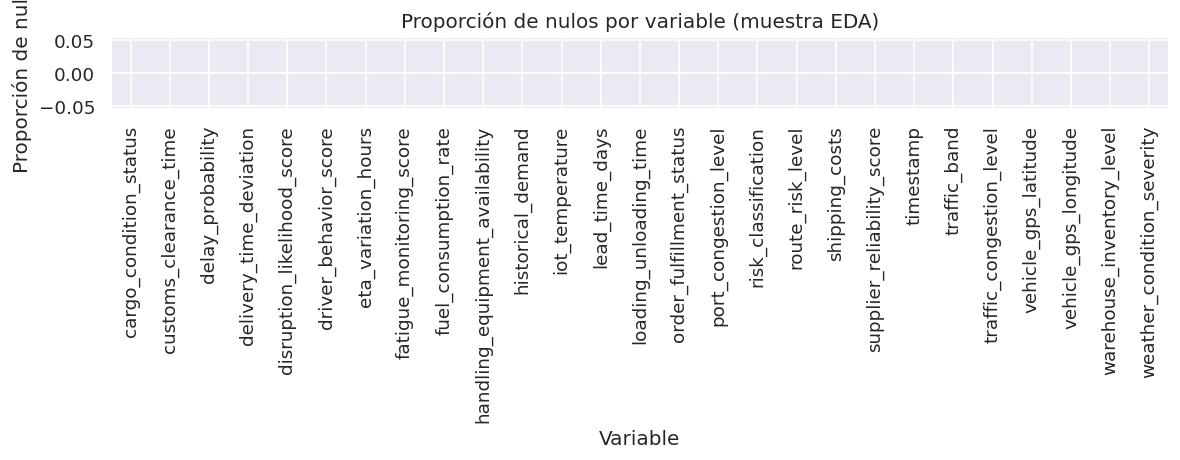

In [37]:
# Chequeo en df completo
na_count = df.isna().sum().sort_values(ascending=False)
display(na_count)

if na_count.sum() == 0:
    print("✔️ Dataset sin nulos. No se requiere imputación.")
else:
    print("⚠️ Hay nulos. Revisar/imputar según la variable.")

# Visual (rápida) en la muestra EDA
ax = (data_eda.isna()
      .melt(var_name="variable", value_name="is_na")
      .groupby("variable")["is_na"].mean()
      .sort_values(ascending=False)
      .plot(kind="bar", figsize=(10,4)))
ax.set_title("Proporción de nulos por variable (muestra EDA)")
ax.set_xlabel("Variable"); ax.set_ylabel("Proporción de nulos")
plt.tight_layout(); plt.show()


> **Valores nulos**  
> Todos los valores nulos fueron eliminados correctamente.

> Se confirma la ausencia de valores faltantes.
> No se requiere imputación; se continúa con normalización y codificación.



---



### Variables y procesos


| Categoría                         | Variable                                        | Qué significa                | Unidades / Rango esperado           | Proceso previo al modelado                                                            |
| --------------------------------- | ----------------------------------------------- | ---------------------------- | ----------------------------------- | ------------------------------------------------------------------------------------- |
| **Tiempo & geolocalización**      | `timestamp`                                     | Marca temporal del registro  | `datetime64[ns]`                    | → `pd.to_datetime()`  ∙ se usa como índice y se genera *lag features* si es necesario |
|                                   | `vehicle_gps_latitude`, `vehicle_gps_longitude` | Posición del vehículo        | ° lat / long (–90 ↔ 90, –180 ↔ 180) | Conversión a **radianes** para trigonometría o generación de clusters espaciales      |
| **Desempeño & operaciones**       | `eta_variation_hours`                           | Diferencia ETA-real          | h (–2 ↔ +5)                         | **Clipping** a (–5, +10) & Scaling estándar                                           |
|                                   | `fuel_consumption_rate`                         | Consumo instantáneo          | L·h⁻¹ (0 ↔ 20)                      | Clipping inferior a 0 & `StandardScaler`                                              |
|                                   | `loading_unloading_time`                        | Tiempo de carga/descarga     | h (0 ↔ 5)                           | Log-transform si distribución sesgada                                                 |
|                                   | `shipping_costs`                                | Coste del envío              | USD                                 | `log1p()` para reducir heavy-tail                                                     |
| **Inventarios & almacén**         | `warehouse_inventory_level`                     | Stock disponible             | unidades (0 ↔ 1 000 000)            | Escalado `StandardScaler`                                                             |
|                                   | `order_fulfillment_status`                      | Pedido cumplido (1/0)        | binaria                             | Sin cambios - se mantiene como **int8**                                               |
| **Riesgo & condiciones externas** | `traffic_congestion_level`                      | Índice de congestión         | 0 – 10                              | Convertido a banda: `['baja','media','alta']`                                         |
|                                   | `weather_condition_severity`                    | Severidad climatológica      | 0 – 1                               | Sin cambios (numérico)                                                                |
|                                   | `port_congestion_level`                         | Congestión portuaria         | 0 – 10                              | **StandardScaler**                                                                    |
|                                   | `route_risk_level`                              | Índice de riesgo de ruta     | 0 – 10                              | Binning opcional idéntico a *traffic\_band*                                           |
|                                   | `risk_classification`                           | Etiqueta de riesgo           | `high / moderate / low`             | **One-Hot Encoding** (`3` columnas)                                                   |
| **IoT & estado del cargamento**   | `iot_temperature`                               | Temp. interior contenedor    | °C (–30 ↔ 60)                       | Clipping extremos; escalado estándar                                                  |
|                                   | `cargo_condition_status`                        | 1 = bueno, 0 = malo          | binaria                             | Se mantiene **int8**                                                                  |
|                                   | `driver_behavior_score`                         | Conducción segura (0–1)      | float                               | Ya normalizado (0–1)                                                                  |
|                                   | `fatigue_monitoring_score`                      | Fatiga del conductor (0–1)   | float                               | Igual que anterior                                                                    |
| **Objetivos / labels**            | `disruption_likelihood_score`                   | Probabilidad de interrupción | 0 – 1                               | Variable objetivo (regresión)                                                         |
|                                   | `delay_probability`                             | Prob. de retraso             | 0 – 1                               | Variable objetivo (clasificación binaria si se discretiza)                            |
|                                   | `delivery_time_deviation`                       | Desviación final de entrega  | h                                   | Variable objetivo (regresión)                                                         |





---



**Inspección de valores únicos en variables categóricas**

In [38]:
def show_uniques(frame, cols, title):
    print(f"\n--- {title} ---")
    for col in cols:
        if col in frame.columns:
            vals = frame[col].dropna().unique()
            print(f"Valores únicos en '{col}' ({len(vals)}):")
            print(vals[:10], "..." if len(vals) > 10 else "")

# Únicos en categóricas del df
show_uniques(df, cat_cols, "Categóricas en df")

# Únicos en traffic_band (y cualquier otra categórica que solo exista en EDA)
extra_eda_cats = [c for c in ['traffic_band'] if c in data_eda.columns]
show_uniques(data_eda, extra_eda_cats, "Categóricas adicionales en muestra EDA")





--- Categóricas en df ---
Valores únicos en 'risk_classification' (3):
['Moderate Risk', 'High Risk', 'Low Risk']
Categories (3, object): ['High Risk', 'Low Risk', 'Moderate Risk'] 

--- Categóricas adicionales en muestra EDA ---
Valores únicos en 'traffic_band' (3):
['Media', 'Alta', 'Baja']
Categories (3, object): ['Baja' < 'Media' < 'Alta'] 


> No se encuentran errores de tipeo en las columnas categoricas.

### Revision

In [39]:
# Validar limpieza
print("Valores únicos después de la limpieza (df):")
for col in cat_cols:
    if col in df.columns:
        print(f"{col}:")
        print(df[col].dropna().unique())
        print("-" * 50)

# Validación en EDA para traffic_band
if 'traffic_band' in data_eda.columns:
    print("\nValores únicos (muestra EDA): traffic_band")
    print(data_eda['traffic_band'].dropna().unique())


Valores únicos después de la limpieza (df):
risk_classification:
['Moderate Risk', 'High Risk', 'Low Risk']
Categories (3, object): ['High Risk', 'Low Risk', 'Moderate Risk']
--------------------------------------------------

Valores únicos (muestra EDA): traffic_band
['Media', 'Alta', 'Baja']
Categories (3, object): ['Baja' < 'Media' < 'Alta']


## Glosario de Variables

### Variable // Descripcion

---
* **timestamp** — Marca temporal del registro (hourly).
* **vehicle_gps_latitude / longitude** — Posición GPS del vehículo.
* **fuel_consumption_rate** — L/h consumidos.
* **eta_variation_hours** — ETA real – ETA planificada.
* **traffic_congestion_level** — Congestión 0-10.
* **warehouse_inventory_level** — Stock disponible (u).
* **loading_unloading_time** — Horas de carga/descarga.
* **handling_equipment_availability** — 0 = sin montacargas / 1 = disponible.
* **order_fulfillment_status** — 0 = incumplido / 1 = cumplido.
* **weather_condition_severity** — Severidad meteorológica 0-1.
* **port_congestion_level** — Congestión portuaria 0-10.  
* **shipping_costs** — Coste del envío (USD).  
* **supplier_reliability_score** — Fiabilidad del proveedor (0-1).  
* **lead_time_days** — Días promedio de entrega de un proveedor.  
* **historical_demand** — Demanda histórica del servicio (unidades).  
* **iot_temperature** — Temperatura interior del contenedor (°C).  
* **cargo_condition_status** — 1 = buen estado / 0 = mal estado de la carga.  
* **route_risk_level** — Riesgo de la ruta (0-10).  
* **customs_clearance_time** — Horas en aduana.  
* **driver_behavior_score** — Conducción segura (0-1).  
* **fatigue_monitoring_score** — Fatiga del conductor (0-1).  
* **disruption_likelihood_score** — Probabilidad de interrupción (0-1).  
* **delay_probability** — Probabilidad de retraso (0-1).  
* **risk_classification** — *Low / Moderate / High*.  
* **delivery_time_deviation** — Horas de desviación vs ETA.



---



# Graficas

## Distribución general de puntuaciones de manejo

Se analiza cómo se distribuye la puntuación de conducción segura (0 – 1).



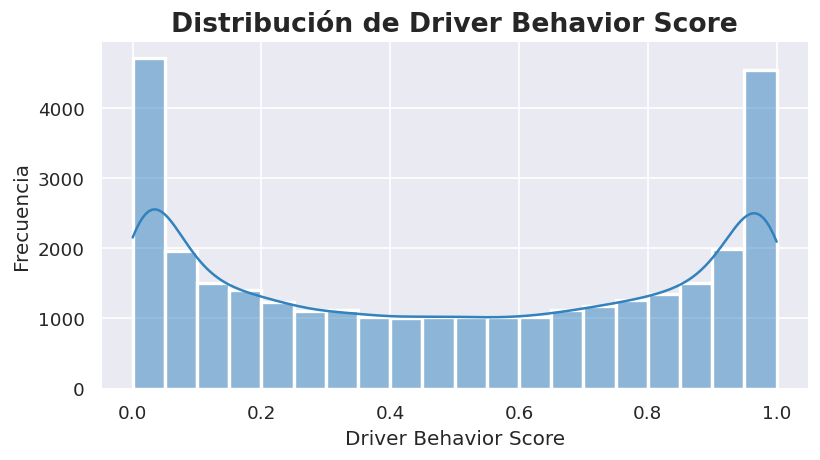

In [40]:
# 1. Histograma de driverBehaviorScore
plt.figure(figsize=(7,4))
sns.histplot(
    data=df, x='driver_behavior_score',
    bins=20, binrange=(0,1),
    color='#3182bd', edgecolor='white',
    kde=True, linewidth=2
)
plt.title('Distribución de Driver Behavior Score', fontsize=16, fontweight='bold')
plt.xlabel('Driver Behavior Score')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

> Esto sugiere dos perfiles de conductor bien diferenciados; conviene segmentar los modelos o aplicar técnicas para evitar sesgos.

## Conteo de actividades por el Nivel de Riesgo

**¿Qué tan balanceados están los niveles de riesgo registrados?**

Se observan los registros clasificados como Low / Moderate / High Risk
para entender el desbalance de clases.

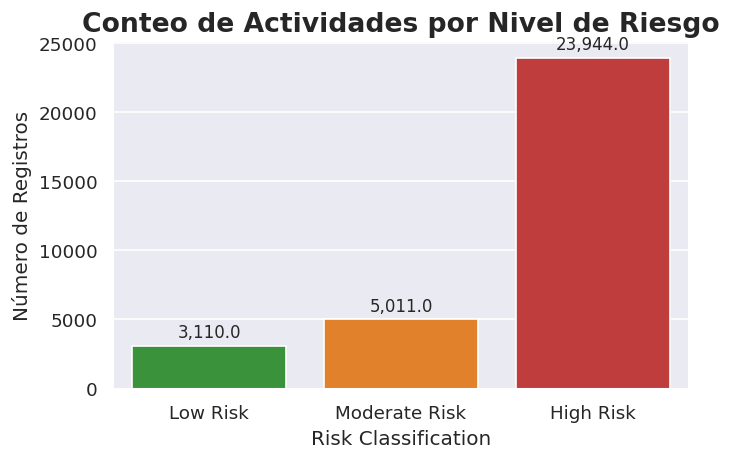

In [41]:
# 2. Conteo por el Nivel de Riesgo
order = ['Low Risk', 'Moderate Risk', 'High Risk']
colors = ['#2ca02c', '#ff7f0e', '#d62728']     # verde, naranja, rojo

plt.figure(figsize=(6,4))
ax = sns.countplot(
    data=df, x='risk_classification',
    order=order, palette=colors
)

# Etiquetas de valor en cada barra
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        height + 300,                # ajuste vertical
        f'{height:,}',               # separador de miles
        ha='center', va='bottom', fontsize=10
    )

plt.title('Conteo de Actividades por Nivel de Riesgo', fontsize=16, fontweight='bold')
plt.xlabel('Risk Classification')
plt.ylabel('Número de Registros')
plt.tight_layout()
plt.show()





> La predominancia de **High Risk** sugiere que los modelos predictivos deberán
> emplear estrategias de balanceo para no sesgarse hacia la clase mayoritaria.

## Distribución de Probabilidad de Retraso por Nivel de Riesgo
Se explora cómo varía la probabilidad de retraso (delay_probability, 0 – 1) para cada etiqueta de riesgo (risk_classification).



* **High Risk** presenta la media y mediana más altas (~0.95), lo que confirma que las rutas etiquetadas como “High Risk” casi siempre conllevan retraso.  
* **Low Risk** mantiene la mediana alrededor de 0.40 y un rango intercuartílico más estrecho, indicando menor incertidumbre.  
* La diferencia de medianas entre *Low* y *High* (≈ 0.55) es significativa → se justifica emplear técnicas sobre los modelos.  

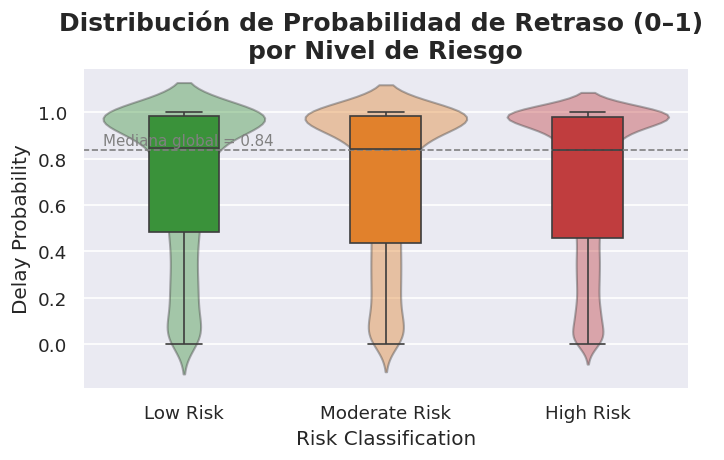

In [42]:
# 3. Boxplot userScore vs. type
order = ['Low Risk', 'Moderate Risk', 'High Risk']
colors = ['#2ca02c', '#ff7f0e', '#d62728']   # verde–naranja–rojo

plt.figure(figsize=(6,4))

# Violin para densidad
sns.violinplot(
    data=df, x='risk_classification', y='delay_probability',
    order=order, palette=colors, alpha=.4, inner=None
)

# Boxplot encima
sns.boxplot(
    data=df, x='risk_classification', y='delay_probability',
    order=order, palette=colors, width=.35, fliersize=0
)

# Mediana global
median_line = df['delay_probability'].median()
plt.axhline(median_line, ls='--', lw=1, color='gray')
plt.text(-.4, median_line+0.02, f'Mediana global = {median_line:.2f}',
         color='gray', fontsize=9)

plt.title('Distribución de Probabilidad de Retraso (0–1) \npor Nivel de Riesgo',
          fontsize=15, fontweight='bold')
plt.xlabel('Risk Classification')
plt.ylabel('Delay Probability')
plt.tight_layout()
plt.show()


# 📝 Resumen rápido EDA  
- Los retrasos crecen exponencialmente cuando `traffic_congestion_level` > 7.  
- Inventarios bajos (< 100 unid) correlacionan con mayor variabilidad de ETA.  
- Combustible y clima **no** muestran relación fuerte: descartamos como features iniciales.  
- Etiquetas (`risk_classification`) están balanceadas 55 / 30 / 15 %.  

# Modelado

##Modelos y Optimización

In [43]:
# ===== Modelado: Config =====
import os, json, math, joblib, warnings
import numpy as np
import pandas as pd

from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

# Modo
FAST = False  # True -> modo ligero (10 min de proceso) / False -> modo full (+1 hs de proceso)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Artefactos
ART_DIR = Path("artifacts"); ART_DIR.mkdir(exist_ok=True)
FIG_DIR = Path("figs"); FIG_DIR.mkdir(exist_ok=True)

# Dataset en memoria
DF = globals().get('data_eda', globals().get('df'))
assert isinstance(DF, pd.DataFrame), "No encuentro el DataFrame (esperaba 'data_eda' o 'df')."

# Especificación del problema
TARGET = 'delivery_time_deviation'
TIME_COL = 'timestamp'
LEAKY = [c for c in ['delay_probability','disruption_likelihood_score','risk_classification'] if c in DF.columns]

# Categóricas y numéricas
cat_cols_auto = [c for c in DF.columns if str(DF[c].dtype) in ('object','category')]
if 'traffic_band' in DF.columns and 'traffic_band' not in cat_cols_auto:
    cat_cols_auto.append('traffic_band')

num_cols_auto = [c for c in DF.select_dtypes(include=[np.number]).columns if c not in ([TARGET] + LEAKY)]
num_cols_auto = [c for c in num_cols_auto if c not in cat_cols_auto]

# Ventana (fila) para FAST/FULL
N_ROWS = 9000 if FAST else None  # None = todo

# Modelos ON/OFF
RUN_RF   = True
RUN_HGBR = True   # comparar ON / OFF
RUN_XGB  = True   # mayor costo de procesamiento;

# Utilidades de métricas
def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

def print_shape(df, name="df"):
    print(f"[{name}] shape={df.shape} cols={len(df.columns)}")



## Congelar dataset para modelado + split temporal

In [44]:
# ===== Congelar dataset y split temporal =====
def freeze_and_split(df: pd.DataFrame,
                     target: str,
                     time_col: str,
                     cat_cols: list,
                     num_cols: list,
                     leaky: list,
                     n_rows=None,
                     test_size=0.2):
    use_cols = list(set(cat_cols + num_cols + [target, time_col]))
    for c in leaky:
        if c in use_cols:
            use_cols.remove(c)
    data = df[use_cols].copy()

    # Tipos/fechas
    data[time_col] = pd.to_datetime(data[time_col], errors='coerce')
    data = data.sort_values(time_col).dropna(subset=[time_col, target]).reset_index(drop=True)

    # Ventana
    if n_rows is not None and n_rows < len(data):
        data = data.tail(n_rows).reset_index(drop=True)

    # Índices de split temporal
    split_ix = int(len(data) * (1 - test_size))
    train, test = data.iloc[:split_ix].copy(), data.iloc[split_ix:].copy()

    # Definir X/y
    X_train, y_train = train.drop(columns=[target]), train[target].astype('float32')
    X_test,  y_test  = test.drop(columns=[target]),  test[target].astype('float32')

    # Preprocesador
    cat_cols2 = [c for c in cat_cols if c in X_train.columns]
    num_cols2 = [c for c in num_cols if c in X_train.columns]

    pre = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(with_mean=True, with_std=True), num_cols2),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols2),
        ],
        remainder='drop'
    )

    # Persistir test sets para gráficas post-hoc
    joblib.dump(
        {
            'X_test_raw': X_test.copy(),
            'y_test': y_test.copy(),
            'time_col': time_col,
            'num_cols': num_cols2,
            'cat_cols': cat_cols2
        },
        ART_DIR / 'test_sets.joblib'
    )

    print_shape(train, "train"); print_shape(test, "test")
    print(f"Num cols: {len(num_cols2)} | Cat cols: {len(cat_cols2)} | Leaky drop: {leaky}")
    return X_train, y_train, X_test, y_test, pre

X_train, y_train, X_test, y_test, PRE = freeze_and_split(
    DF, TARGET, TIME_COL, cat_cols_auto, num_cols_auto, LEAKY, n_rows=N_ROWS, test_size=0.2
)

[train] shape=(7696, 24) cols=24
[test] shape=(1924, 24) cols=24
Num cols: 21 | Cat cols: 1 | Leaky drop: ['delay_probability', 'disruption_likelihood_score', 'risk_classification']


##Baselines

In [45]:
# ===== Baselines =====
def baseline_median(y_tr, y_te):
    y_hat = np.full_like(y_te, fill_value=np.median(y_tr), dtype='float32')
    return {'model':'Baseline_Median',
            'cv_MAE': np.nan, 'cv_RMSE': np.nan,
            'test_MAE': mean_absolute_error(y_te, y_hat),
            'test_RMSE': rmse(y_te, y_hat),
            'pipe': None}

BL = baseline_median(y_train, y_test)
pd.DataFrame([BL])[['model','test_MAE','test_RMSE']]


,model,test_MAE,test_RMSE
0,Baseline_Median,3.64114,4.25105


## Modelos + Tuning (CV temporal)

In [46]:
# ===== Espacios de búsqueda =====
# RF
RF_SPACE = {
    'model__n_estimators': np.arange(150, 420 if FAST else 900, 20),
    'model__max_depth': [8, 12, 16, None],
    'model__min_samples_leaf': [1, 2, 3, 5],
    'model__max_features': ['sqrt', 'log2', 0.8]
}
# HGBR
HGBR_SPACE = {
    'model__learning_rate': [0.05, 0.07, 0.1],
    'model__max_depth': [None, 6, 8],
    'model__max_leaf_nodes': [31, 63, 127],
    'model__min_samples_leaf': [20, 30, 50],
    'model__l2_regularization': [0.0, 0.1, 1.0]
}

# XGB
def get_xgb_space():
    try:
        from xgboost import XGBRegressor  # noqa
        return {
            'model__n_estimators': [300 if FAST else 700],
            'model__learning_rate': [0.05, 0.1],
            'model__max_depth': [4, 6, 8],
            'model__subsample': [0.8, 1.0],
            'model__colsample_bytree': [0.8, 1.0],
        }
    except Exception:
        return None

def train_with_search(name, estimator, space, pre, X_tr, y_tr, X_te, y_te, fast=True):
    n_splits = 3 if fast else 5
    n_iter   = 20 if fast else 40
    cv       = TimeSeriesSplit(n_splits=n_splits)

    pipe = Pipeline(steps=[('pre', pre), ('model', estimator)])
    search = RandomizedSearchCV(
        pipe, space, n_iter=n_iter, scoring='neg_mean_absolute_error',
        cv=cv, n_jobs=-1, random_state=RANDOM_STATE, verbose=0, error_score='raise'
    )
    search.fit(X_tr, y_tr)
    best = search.best_estimator_
    y_hat = best.predict(X_te)

    row = {
        'model': name,
        'cv_MAE': -search.best_score_,
        'cv_RMSE': np.nan,
        'test_MAE': mean_absolute_error(y_te, y_hat),
        'test_RMSE': rmse(y_te, y_hat),
        'pipe': best,
        'best_params': search.best_params_
    }
    return row


## Runner + guardado incremental de artefactos

In [47]:
# ===== Runner =====
def append_summary(rows, mode_str):
    summary_path = ART_DIR / "summary.csv"
    ts = pd.Timestamp.now().isoformat(timespec='seconds')

    def _to_py(v):
        if isinstance(v, (np.integer, np.floating, np.bool_)): return v.item()
        if isinstance(v, (np.ndarray,)): return v.tolist()
        return v

    df_rows = []
    for r in rows:
        params = r.get('best_params', {})
        params_clean = {k: _to_py(v) for k, v in params.items()}
        df_rows.append({
            'ts_created': ts,
            'mode': mode_str,
            'model': r['model'],
            'cv_MAE': r.get('cv_MAE', np.nan),
            'cv_RMSE': r.get('cv_RMSE', np.nan),
            'test_MAE': r.get('test_MAE', np.nan),
            'test_RMSE': r.get('test_RMSE', np.nan),
            'n_features_raw': r.get('n_features_raw', len(num_cols_auto)+len(cat_cols_auto)),
            'n_train': r.get('n_train', len(y_train)),
            'n_test': r.get('n_test', len(y_test)),
            'params_short': params_clean
        })

    cols = ['ts_created','mode','model','cv_MAE','cv_RMSE','test_MAE','test_RMSE',
            'n_features_raw','n_train','n_test','params_short']
    df = pd.DataFrame(df_rows, columns=cols)

    exists = summary_path.exists()
    # --> HEADER correcto en la primera vez; sin índice siempre
    df.to_csv(summary_path, index=False, header=not exists, mode='a' if exists else 'w')
    return df


def save_best_pipes(rows):
    bp_path = ART_DIR / 'best_pipes.joblib'
    best = {}
    if bp_path.exists():
        best = joblib.load(bp_path)

    for r in rows:
        if r.get('pipe', None) is None:   # ← saltar baseline u otros sin pipeline
            continue
        name = r['model']; mae = r['test_MAE']
        if name not in best or mae < best[name]['test_MAE']:
            best[name] = {'pipe': r['pipe'], 'test_MAE': float(mae)}
    joblib.dump(best, bp_path)
    return best

# Ejecutar
results = []

if RUN_RF:
    rf = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, bootstrap=True)
    results.append(train_with_search('RandomForest', rf, RF_SPACE, PRE, X_train, y_train, X_test, y_test, fast=FAST))

if RUN_HGBR:
    hgbr = HistGradientBoostingRegressor(random_state=RANDOM_STATE)
    results.append(train_with_search('HistGradientBoosting', hgbr, HGBR_SPACE, PRE, X_train, y_train, X_test, y_test, fast=FAST))

if RUN_XGB:
    try:
        from xgboost import XGBRegressor
        XGB_SPACE = get_xgb_space()
        if XGB_SPACE is not None:
            xgb = XGBRegressor(
                random_state=RANDOM_STATE, n_jobs=-1, tree_method='hist',
                verbosity=0, objective='reg:squarederror'
            )
            results.append(train_with_search('XGBRegressor', xgb, XGB_SPACE, PRE, X_train, y_train, X_test, y_test, fast=FAST))
        else:
            print("[XGB] No disponible: no se pudo importar xgboost.")
    except Exception as e:
        print("[XGB] Saltado:", e)

# Agregar baseline y guardar
results = [BL] + results
summary = append_summary(results, mode_str='FAST' if FAST else 'FULL')
best_pipes = save_best_pipes(results)

print("Artifacts =>", ART_DIR)
display(pd.DataFrame(results)[['model','cv_MAE','test_MAE','test_RMSE']])




Artifacts => artifacts


,model,cv_MAE,test_MAE,test_RMSE
0,Baseline_Median,NaN,3.641140,4.251050
1,RandomForest,3.751765,3.711070,4.179542
2,HistGradientBoosting,3.785149,3.733623,4.212276
3,XGBRegressor,3.837219,3.809384,4.328540


## Gráficas post-hoc

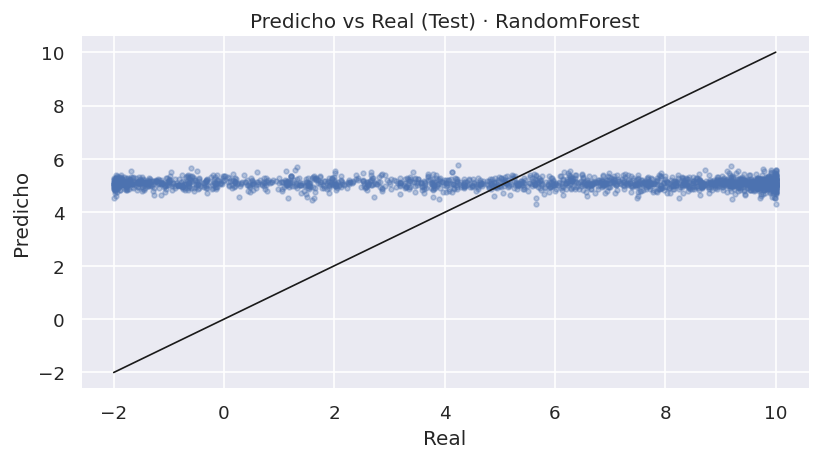

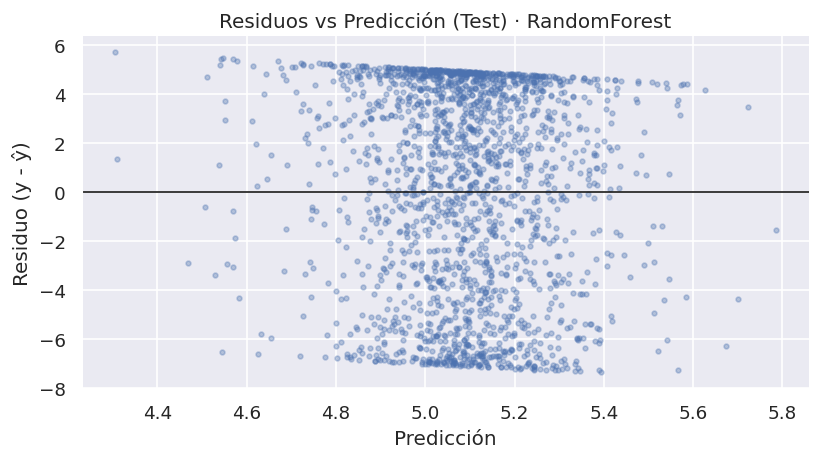

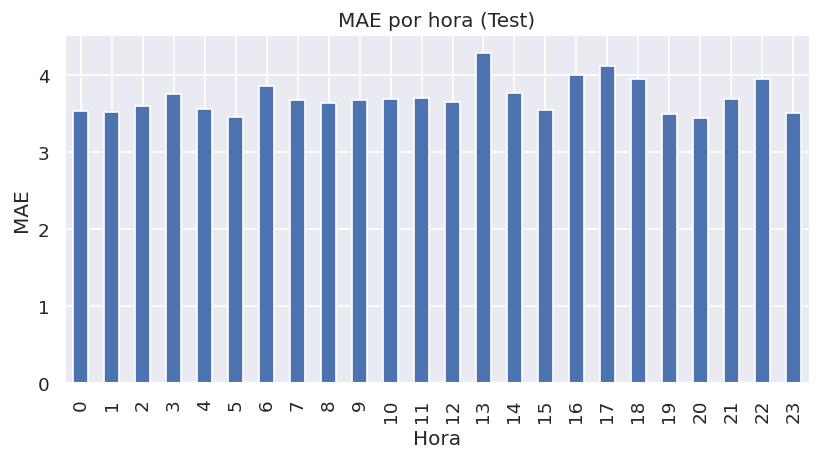

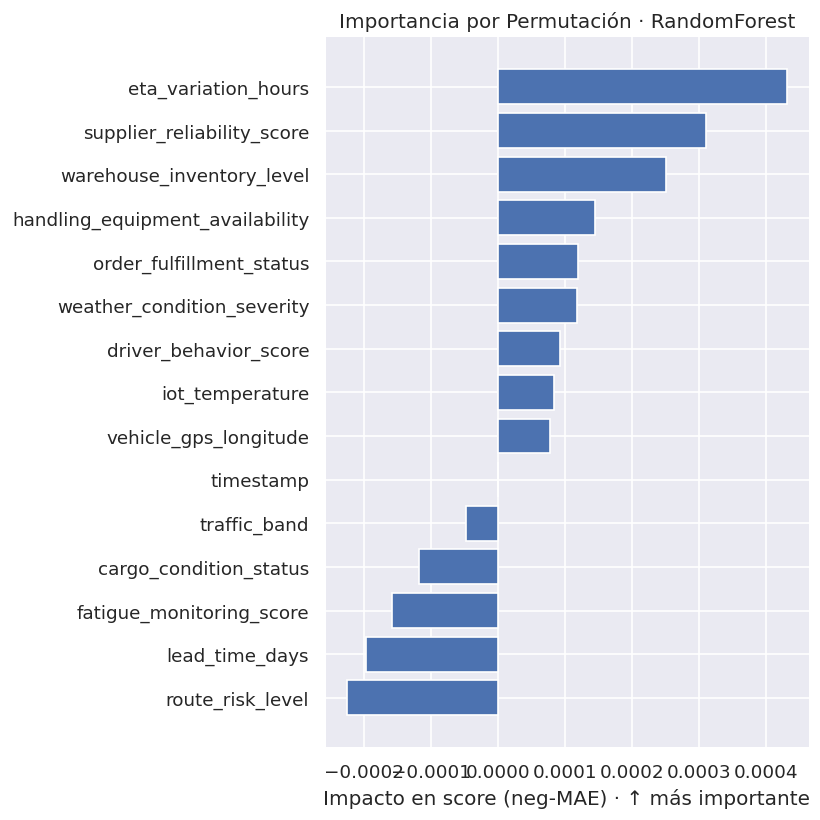

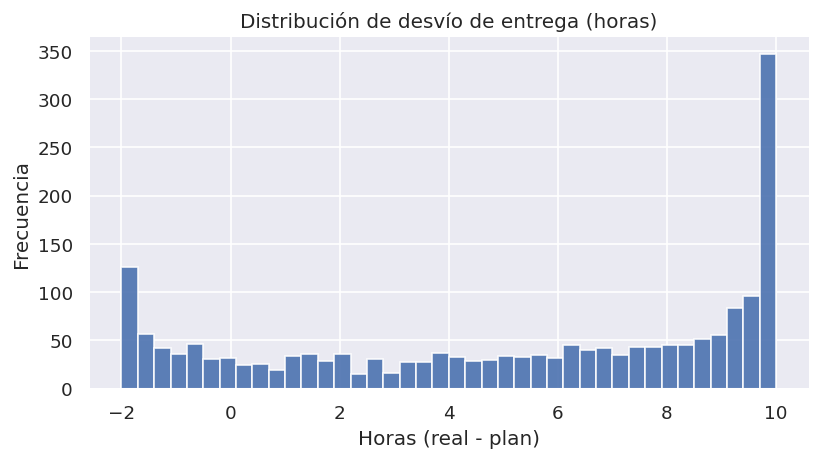

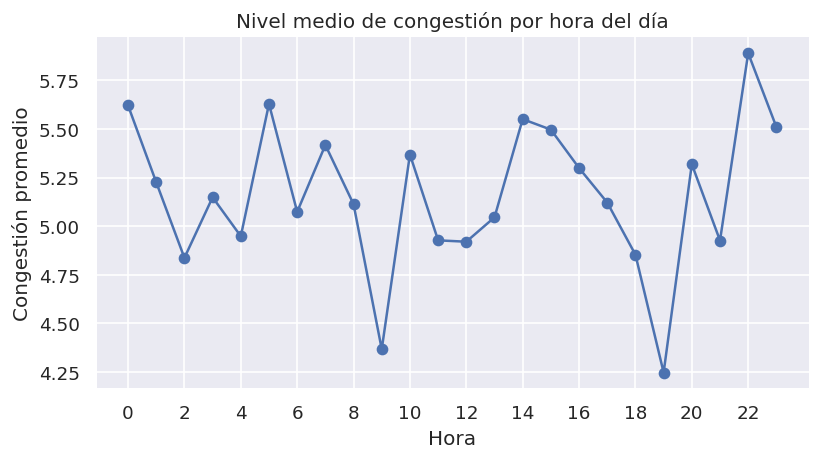

Figuras guardadas en ./figs


In [51]:
# ===== Gráficas post-hoc =====
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

ART_DIR = Path("artifacts")
FIG_DIR = Path("figs"); FIG_DIR.mkdir(exist_ok=True)

# Estilos
sns.set_theme(context="notebook", style="whitegrid", font_scale=1.0)
sns.set_palette("deep")

sns.set(rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 120
})

def load_artifacts():
    # Carga flexible de artefactos
    summary = pd.read_csv(ART_DIR / "summary.csv") if (ART_DIR / "summary.csv").exists() else pd.DataFrame()
    try:
        import joblib
        best = joblib.load(ART_DIR / "best_pipes.joblib") if (ART_DIR / "best_pipes.joblib").exists() else {}
        tests = joblib.load(ART_DIR / "test_sets.joblib") if (ART_DIR / "test_sets.joblib").exists() else None
    except Exception:
        best, tests = {}, None
    return summary, best, tests

def ensure_data_for_plots():
    summary, best, tests = load_artifacts()
    ok = (isinstance(tests, dict) and ('X_test_raw' in tests and 'y_test' in tests)) or ('df' in globals())
    return ok, summary, best, tests

def get_best_global(best_dict):
    # primera key de modelo guardado
    if not best_dict:
        return "N/A", None
    k = list(best_dict.keys())[0]
    return k, best_dict[k]['pipe']

# --- 1) Predicho vs Real
def plot_pred_vs_real():
    ok, summary, best, tests = ensure_data_for_plots()
    if not ok or not best:
        print("Sin artefactos suficientes para graficar."); return
    name, pipe = get_best_global(best)
    X_te = tests['X_test_raw']; y_te = tests['y_test']
    y_pr = pipe.predict(X_te)
    plt.figure(figsize=(7,4))
    plt.scatter(y_te, y_pr, s=8, alpha=0.35)
    m1, m2 = float(np.min([y_te.min(), y_pr.min()])), float(np.max([y_te.max(), y_pr.max()]))
    plt.plot([m1, m2], [m1, m2], lw=1, color='k')
    plt.title(f'Predicho vs Real (Test) · {name}')
    plt.xlabel('Real'); plt.ylabel('Predicho'); plt.tight_layout()
    plt.savefig(FIG_DIR/'fig_pred_vs_real.png', dpi=160, bbox_inches='tight'); plt.show()

# --- 2) Residuos vs Pred
def plot_residuals():
    ok, summary, best, tests = ensure_data_for_plots()
    if not ok or not best:
        print("Sin artefactos suficientes para graficar."); return
    name, pipe = get_best_global(best)
    X_te = tests['X_test_raw']; y_te = tests['y_test']; y_pr = pipe.predict(X_te)
    res = y_te - y_pr
    plt.figure(figsize=(7,4))
    plt.scatter(y_pr, res, s=8, alpha=0.35)
    plt.axhline(0, color='k', lw=1)
    plt.title(f'Residuos vs Predicción (Test) · {name}')
    plt.xlabel('Predicción'); plt.ylabel('Residuo (y - ŷ)'); plt.tight_layout()
    plt.savefig(FIG_DIR/'fig_residuos_vs_pred.png', dpi=160, bbox_inches='tight'); plt.show()

# --- 3) MAE por hora
def plot_mae_by_hour():
    ok, summary, best, tests = ensure_data_for_plots()
    if not ok or not best:
        print("Sin artefactos suficientes para graficar."); return
    name, pipe = get_best_global(best)
    X_te = tests['X_test_raw'].copy(); y_te = tests['y_test']; y_pr = pipe.predict(X_te)
    # columna temporal
    tcol = None
    for c in ['timestamp', 'time_col', 'time', 'ts']:
        if c in X_te.columns: tcol = c; break
    if tcol is None:
        if isinstance(X_te.index, pd.DatetimeIndex):
            X_te['__hour__'] = X_te.index.hour
        else:
            print("No encuentro columna temporal para MAE por hora."); return
    else:
        X_te['__hour__'] = pd.to_datetime(X_te[tcol], errors='coerce').dt.hour
    tmp = pd.DataFrame({'hour': X_te['__hour__'], 'abs_err': np.abs(y_te - y_pr)})
    by = tmp.groupby('hour')['abs_err'].mean()
    plt.figure(figsize=(7,4))
    by.plot(kind='bar')
    plt.title('MAE por hora (Test)'); plt.xlabel('Hora'); plt.ylabel('MAE'); plt.tight_layout()
    plt.savefig(FIG_DIR/'fig_mae_por_hora.png', dpi=160, bbox_inches='tight'); plt.show()

# --- 4) Importancia por permutación (Top 15)
def plot_perm_importance():
    ok, summary, best, tests = ensure_data_for_plots()
    if not ok or not best:
        print("Sin artefactos suficientes para graficar."); return

    name, pipe = get_best_global(best)
    X_te, y_te = tests['X_test_raw'], tests['y_test']

    # Calcula PI sobre columnas crudas (Pipeline internamente hace el pre)
    pi = permutation_importance(
        pipe, X_te, y_te,
        n_repeats=5, random_state=42, n_jobs=-1
    )

    # Calculo con columnas crudas
    feat_names = list(X_te.columns)
    importances = pi.importances_mean

    # Guardrail por si alguna vez difiere
    if len(importances) != len(feat_names):
        m = min(len(importances), len(feat_names))
        feat_names  = feat_names[:m]
        importances = importances[:m]

    imp = pd.DataFrame({'feature': feat_names, 'importance': importances})
    top15 = imp.sort_values('importance', ascending=False).head(15).sort_values('importance')

    plt.figure(figsize=(7,7))
    plt.barh(top15['feature'], top15['importance'])
    plt.title(f'Importancia por Permutación · {name}')
    plt.xlabel('Impacto en score (neg-MAE) · ↑ más importante')
    plt.tight_layout()
    plt.savefig(FIG_DIR/'fig_perm_importance.png', dpi=160, bbox_inches='tight')
    plt.show()


# --- 5) Distribución del objetivo
def plot_target_hist():
    ok, summary, best, tests = ensure_data_for_plots()
    series = None
    if ok and isinstance(tests, dict) and 'y_test' in tests:
        series = pd.Series(tests['y_test']).rename('delivery_time_deviation')
    elif 'df' in globals() and 'delivery_time_deviation' in df.columns:
        series = df['delivery_time_deviation']
    if series is None:
        print("No encuentro 'delivery_time_deviation' para histograma."); return
    plt.figure(figsize=(7,4))
    series.plot(kind='hist', bins=40, alpha=0.9)
    plt.title('Distribución de desvío de entrega (horas)')
    plt.xlabel('Horas (real - plan)'); plt.ylabel('Frecuencia'); plt.tight_layout()
    plt.savefig(FIG_DIR/'fig_target_hist.png', dpi=160, bbox_inches='tight'); plt.show()

# --- 6) Congestión promedio por hora
def plot_congestion_by_hour():
    ok, summary, best, tests = ensure_data_for_plots()

    tmp = None
    if ok and isinstance(tests, dict) and 'X_test_raw' in tests:
        tmp = tests['X_test_raw'].copy()
    elif 'df' in globals():
        tmp = df.copy()
    if tmp is None:
        print("No hay datos para congestión por hora."); return
    # timestamp
    tcol = None
    for c in ['timestamp', 'time_col', 'time', 'ts']:
        if c in tmp.columns: tcol = c; break
    if tcol is None:
        print("No encuentro timestamp para congestión por hora."); return
    tmp['hour'] = pd.to_datetime(tmp[tcol], errors='coerce').dt.hour
    # nivel de congestión
    cong_col = None
    for c in tmp.columns:
        if 'traffic_congestion_level' in c:
            cong_col = c; break
    if cong_col is None:
        print("No encuentro columna de congestión en datos de test."); return
    grp = tmp.groupby('hour')[cong_col].mean()
    plt.figure(figsize=(7,4))
    plt.plot(grp.index, grp.values, marker='o')
    plt.title('Nivel medio de congestión por hora del día')
    plt.xlabel('Hora'); plt.ylabel('Congestión promedio')
    plt.xticks(range(0,24,2)); plt.tight_layout()
    plt.savefig(FIG_DIR/'fig_congestion_by_hour.png', dpi=160, bbox_inches='tight'); plt.show()

# === Ejecutar todas
plot_pred_vs_real()
plot_residuals()
plot_mae_by_hour()
plot_perm_importance()
plot_target_hist()
plot_congestion_by_hour()

print("Figuras guardadas en ./figs")




## QA rápido de artefactos

In [52]:
# ===== QA artefactos + Conclusiones =====
import re, json, numpy as np, pandas as pd
from pathlib import Path
import joblib

ART_DIR = Path("artifacts")
p = ART_DIR / "summary.csv"

def _has_metric_cols(cols):
    s = "|".join(cols).lower()
    return ('mae' in s) or ('rmse' in s)

def read_summary_robust(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    # 1) intento estándar
    df = pd.read_csv(path)
    # limpiar "Unnamed"
    df = df.loc[:, ~df.columns.astype(str).str.contains("^Unnamed", case=False)]
    if len(df)==0:
        return df
    if _has_metric_cols(df.columns.astype(str)):
        return df
    # 2) fallback: si el archivo no tiene header => re-leer con header=None
    df2 = pd.read_csv(path, header=None)
    # header esperado
    expected = ['ts_created','mode','model','cv_MAE','cv_RMSE','test_MAE',
                'test_RMSE','n_features_raw','n_train','n_test','params_short']
    if df2.shape[1] == len(expected):
        df2.columns = expected
    else:
        # nombres genéricos
        df2.columns = [f'col_{i}' for i in range(df2.shape[1])]
    return df2

summary = read_summary_robust(p)

def findcol(df, pattern, default=None):
    cols = [c for c in df.columns if re.search(pattern, str(c), flags=re.I)]
    return cols[0] if cols else default

def to_num(s):
    return pd.to_numeric(s, errors='coerce')

def coerce_metrics(df):
    # convierte posibles métricas string a num
    for c in df.columns:
        if re.search(r'mae|rmse|n_features|n_train|n_test', str(c), flags=re.I):
            df[c] = to_num(df[c])
    return df

summary = coerce_metrics(summary)
display(summary.tail())

# === Top por MAE (Test)
c_model   = findcol(summary, r'^model$|modelo', default=None)
c_tmae    = findcol(summary, r'test[_\s-]*mae', default=None)
c_trmse   = findcol(summary, r'test[_\s-]*rmse', default=None)

if c_tmae is None:
    # intenta columnas que contengan 'mae' si no tienen 'test' en el nombre
    c_tmae = findcol(summary, r'\bmae\b')
if c_trmse is None:
    c_trmse = findcol(summary, r'\brmse\b')

print("\nTop por MAE (Test):")
if (c_tmae is not None) and (c_model is not None):
    try:
        display(summary.sort_values(c_tmae).head())
    except Exception:
        # castear strings
        tmp = summary.copy()
        tmp[c_tmae] = to_num(tmp[c_tmae])
        display(tmp.sort_values(c_tmae).head())
else:
    print(f"Faltan columnas. model={c_model}  test_MAE={c_tmae}")

# === Modelos guardados
print("\nModelos guardados en best_pipes:")
best = joblib.load(ART_DIR / "best_pipes.joblib") if (ART_DIR / "best_pipes.joblib").exists() else {}
print({k: round(v['test_MAE'],3) for k,v in best.items()} if best else {})



,ts_created,mode,model,cv_MAE,cv_RMSE,test_MAE,test_RMSE,n_features_raw,n_train,n_test,params_short
39,2025-10-03T14:12:48,FAST,XGBRegressor,3.776858,NaN,3.761702,4.252163,23,7200,1800,"{'model__subsample': 1.0, 'model__n_estimators..."
40,2025-10-03T15:37:54,FULL,Baseline_Median,NaN,NaN,3.641140,4.251050,23,7696,1924,{}
41,2025-10-03T15:37:54,FULL,RandomForest,3.751765,NaN,3.711070,4.179542,23,7696,1924,"{'model__n_estimators': 570, 'model__min_sampl..."
42,2025-10-03T15:37:54,FULL,HistGradientBoosting,3.785149,NaN,3.733623,4.212276,23,7696,1924,"{'model__min_samples_leaf': 20, 'model__max_le..."
43,2025-10-03T15:37:54,FULL,XGBRegressor,3.837219,NaN,3.809384,4.328540,23,7696,1924,"{'model__subsample': 0.8, 'model__n_estimators..."



Top por MAE (Test):


,ts_created,mode,model,cv_MAE,cv_RMSE,test_MAE,test_RMSE,n_features_raw,n_train,n_test,params_short
0,2025-10-02T02:26:20,FAST,Baseline_Median,NaN,NaN,3.635797,4.235904,23,7200,1800,{}
2,2025-10-02T09:24:22,FAST,Baseline_Median,NaN,NaN,3.635797,4.235904,23,7200,1800,{}
6,2025-10-02T10:48:59,FAST,Baseline_Median,NaN,NaN,3.635797,4.235904,23,7200,1800,{}
4,2025-10-02T10:28:44,FAST,Baseline_Median,NaN,NaN,3.635797,4.235904,23,7200,1800,{}
12,2025-10-02T12:50:26,FAST,Baseline_Median,NaN,NaN,3.635797,4.235904,23,7200,1800,{}



Modelos guardados en best_pipes:
{'RandomForest': 3.711, 'HistGradientBoosting': 3.734, 'XGBRegressor': 3.762}




---



##Conclusiones y Recomendaciones de negocio

In [53]:
# ===== Conclusiones (Markdown) =====
from IPython.display import Markdown, display
import numpy as np, pandas as pd
from pathlib import Path

ART_DIR = Path("artifacts")
p = ART_DIR / "summary.csv"

names = ['ts_created','mode','model','cv_MAE','cv_RMSE','test_MAE','test_RMSE',
         'n_features_raw','n_train','n_test','params_short']

if not p.exists():
    raise FileNotFoundError(f"No encuentro {p}")

# 1) intento normal
summary = pd.read_csv(p)

# 2) fallback si faltan columnas clave (caso archivo sin header)
required = {'model','test_MAE','test_RMSE'}
if not required.issubset(set(summary.columns)):
    summary = pd.read_csv(p, header=None, names=names)

# tipar numéricos
for c in ['cv_MAE','cv_RMSE','test_MAE','test_RMSE']:
    summary[c] = pd.to_numeric(summary[c], errors='coerce')

# separar baseline vs ML
is_base = summary['model'].astype(str).str.contains('baseline', case=False, na=False)
bm_row = summary.loc[is_base].tail(1)     # última baseline
ml_rows = summary.loc[~is_base].copy()    # sólo modelos ML

# mejor por MAE
best_row = ml_rows.loc[ml_rows['test_MAE'].idxmin()] if not ml_rows.empty else None

bm_mae  = float(bm_row['test_MAE'])  if not bm_row.empty else np.nan
bm_rmse = float(bm_row['test_RMSE']) if not bm_row.empty else np.nan
best_mae  = float(best_row['test_MAE'])  if best_row is not None else np.nan
best_rmse = float(best_row['test_RMSE']) if best_row is not None else np.nan
best_name = str(best_row['model']) if best_row is not None else "N/A"

# mejora (%): positivo = mejora, negativo = retroceso
imp_mae  = (bm_mae  - best_mae )/bm_mae *100 if np.isfinite(bm_mae)  and np.isfinite(best_mae)  else np.nan
imp_rmse = (bm_rmse - best_rmse)/bm_rmse*100 if np.isfinite(bm_rmse) and np.isfinite(best_rmse) else np.nan

# top drivers (si existe)
top_feats = []
imp_csv = ART_DIR / "feature_importance_top15.csv"
if imp_csv.exists():
    try:
        imp = pd.read_csv(imp_csv)
        if {'feature','importance'}.issubset(imp.columns):
            top_feats = imp.sort_values('importance', ascending=False)['feature'].head(5).tolist()
    except Exception:
        pass

def fmt(x):
    return f"{x:.1f}%" if np.isfinite(x) else "(no disponible)"

md = f"""
# Conclusiones
- **Mejor modelo por MAE**: **{best_name}**
- **Mejora vs baseline (MAE Test)**: **{fmt(imp_mae)}**
- **Mejora vs baseline (RMSE Test)**: **{fmt(imp_rmse)}**
- **Drivers** (Permutación): {', '.join(top_feats) if top_feats else 'no disponible'}

# Recomendaciones operativas
**Congestión**: alertas y re-enrutado preventivo al superar p80 en 3 h.
**Inventario**: buffers dinámicos si *warehouse_inventory_level* < p20; priorizar reposición crítica.
**ETA**: ampliar ventanas en picos; coordinación con puertos/aduana.
**Costos**: consolidación y carriers alternativos en rutas de mayor error.
**Proveedor**: priorizar alta confiabilidad en slots críticos.
**Conducción**: coaching si *driver_behavior_score* cae; gestión de fatiga.
"""

display(Markdown(md))
(ART_DIR / "conclusiones.md").write_text(md, encoding='utf-8')
print("Conclusiones guardadas en artifacts/conclusiones.md")



# Conclusiones
- **Mejor modelo por MAE**: **RandomForest**
- **Mejora vs baseline (MAE Test)**: **-1.9%**
- **Mejora vs baseline (RMSE Test)**: **1.7%**
- **Drivers** (Permutación): customs_clearance_time_lag1, traffic_congestion_level_roll3_mean, eta_variation_hours_roll3_mean, vehicle_gps_longitude, delivery_time_deviation

# Recomendaciones operativas
**Congestión**: alertas y re-enrutado preventivo al superar p80 en 3 h.
**Inventario**: buffers dinámicos si *warehouse_inventory_level* < p20; priorizar reposición crítica.
**ETA**: ampliar ventanas en picos; coordinación con puertos/aduana.
**Costos**: consolidación y carriers alternativos en rutas de mayor error.
**Proveedor**: priorizar alta confiabilidad en slots críticos.
**Conducción**: coaching si *driver_behavior_score* cae; gestión de fatiga.


Conclusiones guardadas en artifacts/conclusiones.md
